### Mar 11 quadratic zeeman

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt
from uncertainties import ufloat, unumpy

import Methods as m
import importlib
importlib.reload(m)

<module 'Methods' from '/Users/markzhitnitsky/Desktop/School/2025-26 Year/PHYS409/Experiment 2 - Optical Pumping/Code/Methods.py'>

In [2]:
freq = 195
savename = "5s measurement Mar 9 - " + str(freq) + 'kHz'
time, y1, y2, y2_norm = m.read_transmission_csv('./data/Mar 9 measurement/NewFile' + str(freq) + 'kHz' + '.csv')

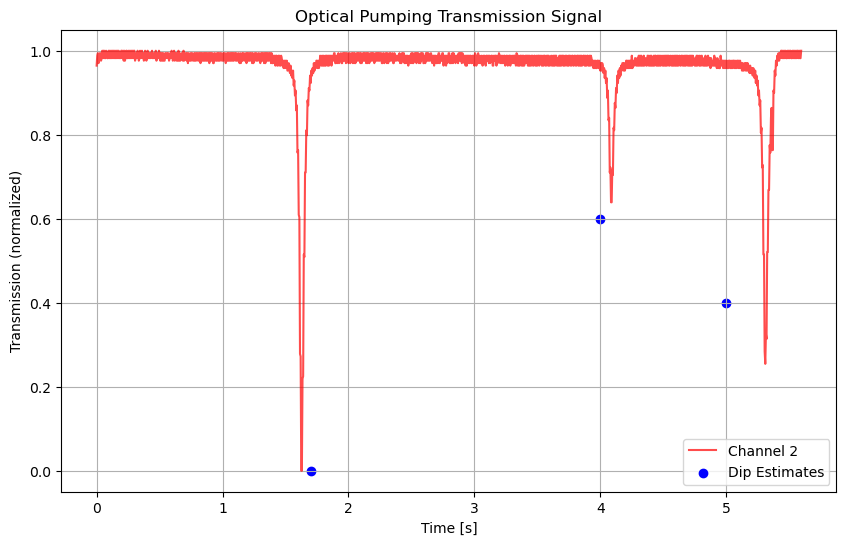

In [6]:
t0 = 0.4
nCut = (t0 // (time[1] - time[0])).astype(int)

time_cutFirst = time[nCut:] - t0
y2_norm_cutFirst = y2_norm[nCut:]

x0s = np.array([1.7,4,5])

m.plot_normalized_transmission(time_cutFirst, y2_norm_cutFirst, x0s, savename)

In [7]:
#    (A, h1, g1, x0_1, h2, g2, x0_2,  h3, g3, x0_3):
variables = ["A", "h1", "g1", "x0_1", "h2", "g2", "x0_2",  "h3", "g3", "x0_3"]
p0 = (1, 1, 0.3, x0s[0], 0.3, 0.1, x0s[1], 0.5, 0.1, x0s[2])
lower_bound = (0,0,0,0,0,0,0,0,0,0)
upper_bound = (2,2,2,100,2,2,100,2,2,100)
bounds = [lower_bound, upper_bound]
popt, pcov = curve_fit(m.multi_lorentz, time_cutFirst, y2_norm_cutFirst, p0=p0,bounds=bounds)
perr = np.sqrt(np.diag(pcov))
for val, name in zip(popt,variables):
    print(name, val)

A 0.9827708894138384
h1 0.9758011141343211
g1 0.017287179121198096
x0_1 1.6287321627932716
h2 0.33372756689779276
g2 0.019996117516368945
x0_2 4.088588645385683
h3 0.7149110386843821
g3 0.021025731683472416
x0_3 5.312950032518317


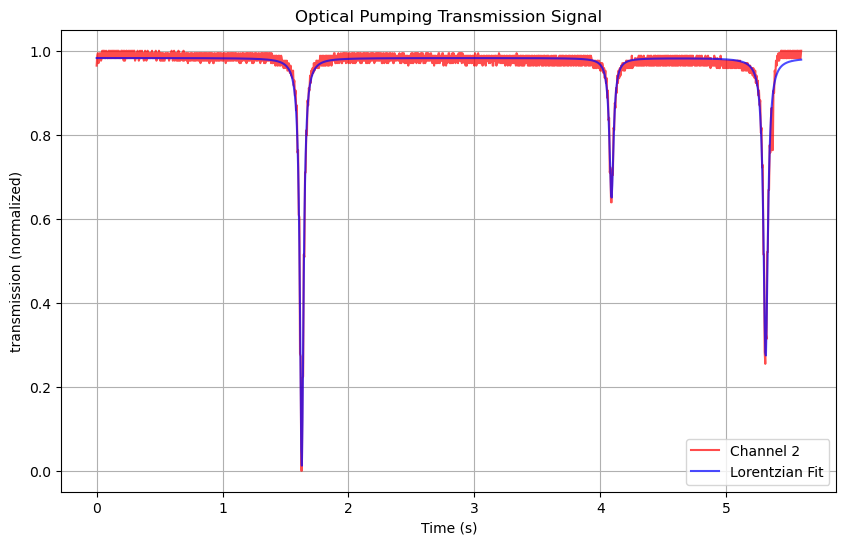

In [8]:
m.plot_fitted_transmission(time_cutFirst, y2_norm_cutFirst, popt, "fit to " + savename)


In [9]:
x0_1_u = ufloat(popt[3], perr[3]) + t0
x0_2_u = ufloat(popt[6], perr[6]) + t0
x0_3_u = ufloat(popt[9], perr[9]) + t0

dt = time[1] - time[0]
x0_1_index = int(x0_1_u.n // dt)
x0_2_index = int(x0_2_u.n // dt)
x0_3_index = int(x0_3_u.n // dt)

numAvg = 10


bShift = ufloat(0,0) # range shifted, either get from data or write down dial position idk # TODO: adjust this


v_1 = ufloat(np.mean(y1[x0_1_index - numAvg : x0_1_index + numAvg]),
             np.std(y1[x0_1_index - numAvg : x0_1_index + numAvg]) / np.sqrt(2*numAvg))
v_2 = ufloat(np.mean(y1[x0_2_index - numAvg : x0_2_index + numAvg]),
             np.std(y1[x0_2_index - numAvg : x0_2_index + numAvg]) / np.sqrt(2*numAvg))
v_3 = ufloat(np.mean(y1[x0_3_index - numAvg : x0_3_index + numAvg]),
             np.std(y1[x0_3_index - numAvg : x0_3_index + numAvg]) / np.sqrt(2*numAvg))

VtoB = ufloat(0.6 * 10**(-4) / 10,0.6 * 10**(-4) / 10/100) # this factor of 10 is only for measurements up to and including Mar 9

Rb_85 = (v_2 - v_1) * VtoB + bShift
Rb_87 = (v_3 - v_1) * VtoB + bShift

print(f"Rb87: {Rb_87:.3e} T")
print(f"Rb85: {Rb_85:.3e} T")

Rb87: (4.037+/-0.050)e-05 T
R 85: (2.712+/-0.038)e-05 T


In [10]:
filepath = 'models/BFreqRatioQuadratic.csv'

m.append_to_v_ratio_csv(freq, Rb_87, Rb_85, filepath)